In [1]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sbn 
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
#% matplotlib notebook

In [2]:
data=pd.read_csv('train_bank.csv')
databank=data.copy()
pd.set_option('Display.max_columns',data.shape[0])
databank

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
databank.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [4]:
#suprression de la colonne 'Loan_ID' qui ne sert a rien 
databank.drop(columns='Loan_ID',axis=0,inplace=True)
databank

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [5]:
databank.select_dtypes(object)

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,Urban,Y
1,Male,Yes,1,Graduate,No,Rural,N
2,Male,Yes,0,Graduate,Yes,Urban,Y
3,Male,Yes,0,Not Graduate,No,Urban,Y
4,Male,No,0,Graduate,No,Urban,Y
...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,Rural,Y
610,Male,Yes,3+,Graduate,No,Rural,Y
611,Male,Yes,1,Graduate,No,Urban,Y
612,Male,Yes,2,Graduate,No,Urban,Y


In [6]:
# division du dataset en cat/num 
liste_categorielle =[]

for col in databank.select_dtypes(object):
        liste_categorielle.append(col)
liste_numerique=[col for col in list(databank.columns) if col not in liste_categorielle]

data_categorielle=databank[liste_categorielle]

data_numerique=databank[liste_numerique]
data_categorielle.isna().sum()

Gender           13
Married           3
Dependents       15
Education         0
Self_Employed    32
Property_Area     0
Loan_Status       0
dtype: int64

In [7]:
liste_categorielle

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [8]:
data_numerique.isna().sum()

ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
dtype: int64

In [9]:
#une fonction qui permet de remplacer les donnees manquantes
def fonction_Encodage1(data_categorielle,data_numerique):
    #pertmet de remplacer les valeurs manquantes par le plus frequent .
    def f_cat(dat_categorielle):
        nouveau=data_categorielle.apply((lambda x: x.fillna(x.value_counts().index[0])))
        #databank.Gender.value_counts().index[0]
        for col in list(data_categorielle.columns):
             nouveau[col]=LabelEncoder().fit_transform(data_categorielle[col])
        return nouveau
    def f_num(data_numerique):
        return data_numerique.apply(lambda x: x.fillna(value=x.mean()))
    x= pd.concat((f_cat(data_categorielle),f_num(data_numerique)),axis=1)
    print(x.isna().sum())
    return x

x_sans=fonction_Encodage1(data_categorielle,data_numerique)
x_sans

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
Property_Area        0
Loan_Status          0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
dtype: int64


,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,1,0,0,0,0,2,1,5849,0.0,146.412162,360.0,1.0
1,1,1,1,0,0,0,0,4583,1508.0,128.000000,360.0,1.0
2,1,1,0,0,1,2,1,3000,0.0,66.000000,360.0,1.0
3,1,1,0,1,0,2,1,2583,2358.0,120.000000,360.0,1.0
4,1,0,0,0,0,2,1,6000,0.0,141.000000,360.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,0,1,2900,0.0,71.000000,360.0,1.0
610,1,1,3,0,0,0,1,4106,0.0,40.000000,180.0,1.0
611,1,1,1,0,0,2,1,8072,240.0,253.000000,360.0,1.0
612,1,1,2,0,0,2,1,7583,0.0,187.000000,360.0,1.0


In [10]:
#permet juste de faire un dropna
def fonction_Encodage2(dataframe):
    data=dataframe.dropna(axis=0).copy()
    for col in liste_categorielle:
        data[col]=LabelEncoder().fit_transform(data[col])
    return pd.concat((data[liste_categorielle],data[liste_numerique]),axis=1)
x_avec_dropna=fonction_Encodage2(databank)
x_avec_dropna

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
1,1,1,1,0,0,0,0,4583,1508.0,128.0,360.0,1.0
2,1,1,0,0,1,2,1,3000,0.0,66.0,360.0,1.0
3,1,1,0,1,0,2,1,2583,2358.0,120.0,360.0,1.0
4,1,0,0,0,0,2,1,6000,0.0,141.0,360.0,1.0
5,1,1,2,0,1,2,1,5417,4196.0,267.0,360.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,0,1,2900,0.0,71.0,360.0,1.0
610,1,1,3,0,0,0,1,4106,0.0,40.0,180.0,1.0
611,1,1,1,0,0,2,1,8072,240.0,253.0,360.0,1.0
612,1,1,2,0,0,2,1,7583,0.0,187.0,360.0,1.0


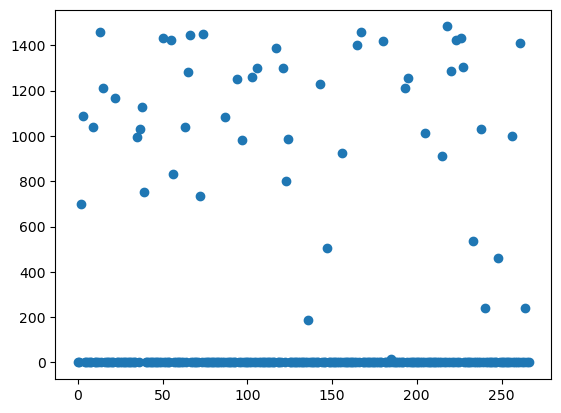

In [11]:
#suppression des valeurs aberante dans LoanAmount
x_avec_dropna=x_avec_dropna[x_avec_dropna.CoapplicantIncome<1500]
plt.scatter(x=np.arange(0,len(x_avec_dropna.CoapplicantIncome)),y=x_avec_dropna.CoapplicantIncome)

In [12]:
x,y=x_avec_dropna.drop(columns='Loan_Status'),x_avec_dropna['Loan_Status']

# Modelisation 

In [13]:
from sklearn.model_selection import StratifiedShuffleSplit
#permet de mettre une partie des donnees du train dans notre test.
Split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train, test in Split.split(x,y):#ns retourne deux index , puis on selectionne le data avec les index equivalent  
    xtrain,xtest=x.iloc[train,:],x.iloc[test,:]
    ytrain,ytest=y.iloc[train],y.iloc[test]
xtrain
#xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

,Gender,Married,Dependents,Education,Self_Employed,Property_Area,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
206,0,0,0,0,0,2,3244,0.0,80.0,360.0,1.0
580,1,1,2,0,0,1,6540,0.0,205.0,360.0,1.0
115,1,1,1,0,0,0,14583,0.0,185.0,180.0,1.0
262,0,0,1,0,0,1,3481,0.0,155.0,36.0,1.0
266,1,1,2,0,0,1,4708,1387.0,150.0,360.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
247,1,1,1,1,0,2,6608,0.0,137.0,180.0,1.0
147,1,1,1,0,0,2,1538,1425.0,30.0,360.0,1.0
80,0,0,0,0,0,1,3846,0.0,111.0,360.0,1.0
239,1,1,1,0,0,1,3315,0.0,96.0,360.0,1.0


In [14]:
xtrain.dtypes

Gender                 int32
Married                int32
Dependents             int32
Education              int32
Self_Employed          int32
Property_Area          int32
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
dtype: object

In [15]:
def colum_transform_type(dataframe):
    dataframe=dataframe.copy()
    list_colums=list(dataframe.columns)
    cat_columns=[column for column in list_colums if column not in ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term']]
    for column in list_colums:
        if column not in cat_columns:
            dataframe[column]=dataframe[column].astype('float')
        else:
            dataframe[column]=dataframe[column].astype('object')
    return dataframe

In [16]:
xtrain,xtest=colum_transform_type(xtrain),colum_transform_type(xtest)

In [24]:
from sklearn.model_selection import train_test_split, validation_curve,learning_curve,ShuffleSplit,KFold,StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report,f1_score,accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import sklearn
from sklearn.feature_selection import f_classif,SelectKBest
#de model de classification choist
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import KNNImputer
#model=LogisticRegression(random_state=42,max_iter=2000)
transformer=[MinMaxScaler(),StandardScaler(),RobustScaler()]
#model=make_pipeline(SelectKBest(f_classif,k=2),LogisticRegression(random_state=42,max_iter=1000))
from sklearn.compose import make_column_selector ,make_column_transformer
selector=make_column_transformer((StandardScaler(),make_column_selector(dtype_include='float64')),
                                (OrdinalEncoder(),make_column_selector(dtype_exclude='float64')))

model=make_pipeline(selector,LogisticRegression(random_state=42,max_iter=10000))

In [25]:
def model_Evaluation(model):
    
    model.fit(xtrain,ytrain)
    model.score(xtrain,ytrain)
    y_prediction=model.predict(xtest)
    print(y_prediction)
    print(confusion_matrix(ytest,y_prediction))
    print(classification_report(ytest,y_prediction))
    cv=ShuffleSplit(4,train_size=0.8)
    #sklearn.metrics.f1_score
    nombre_pts,trainscore,testscore=learning_curve(model,xtrain,ytrain,scoring= 'accuracy' ,cv=cv,
                                                   train_sizes=np.linspace(0.1,1,10))
    #print(trainscore)
    plt.figure(figsize=(8,8))
    plt.title('Evolution de score selon la quantite de donnee fournit')
    plt.plot(nombre_pts,trainscore.mean(axis=1),label='trainscore')
    plt.plot(nombre_pts,testscore.mean(axis=1),label='testscore')
    plt.legend()
    plt.show()

[1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1
 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1]
[[ 9  8]
 [ 0 37]]
              precision    recall  f1-score   support

           0       1.00      0.53      0.69        17
           1       0.82      1.00      0.90        37

    accuracy                           0.85        54
   macro avg       0.91      0.76      0.80        54
weighted avg       0.88      0.85      0.84        54



C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 279, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 371, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_scorer.py", line 89, in _cache

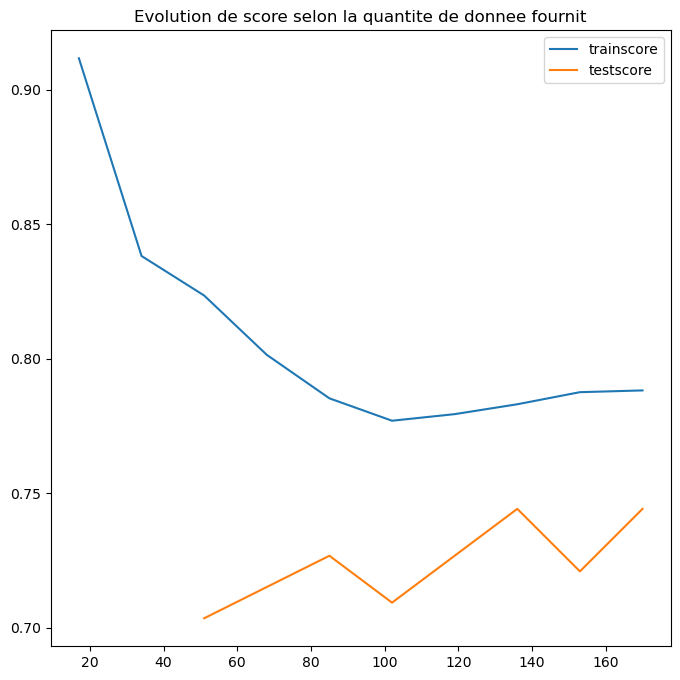

In [26]:
model_Evaluation(model)

In [27]:
model.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x0000027C95FCB890>),
                                   ('ordinalencoder', OrdinalEncoder(),
                                    <sklearn.compose._column_transformer.make_column_selector object at 0x0000027C95FCB0E0>)])),
  ('logisticregression', LogisticRegression(max_iter=10000, random_state=42))],
 'verbose': False,
 'columntransformer': ColumnTransformer(transformers=[('standardscaler', StandardScaler(),
                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000027C95FCB890>),
                                 ('ordinalencoder', OrdinalEncoder(),
                                  <sklearn.compose._column_transformer.make_column_selector object at 0x0000027C95FCB0E0>)]),
 'logisticregression': LogisticRegression

In [28]:
#la selection de variabkle 
from sklearn.feature_selection import RFECV
selecteur=RFECV(LogisticRegression(random_state=42,max_iter=1000),step=1,min_features_to_select=5,cv=3)
modele=make_pipeline(selecteur,model)
modele.fit(xtrain,ytrain)
modele.score(xtrain,ytrain)
y_predict=modele.predict(xtest)
f1_score(ytest,y_predict)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

ValueError: make_column_selector can only be applied to pandas dataframes

In [29]:
selecteur.fit_transform(xtrain,ytrain)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

array([[0, 0, 0, 0, 1.0],
       [1, 1, 0, 0, 1.0],
       [1, 1, 0, 0, 1.0],
       ...,
       [0, 0, 0, 0, 1.0],
       [1, 1, 0, 0, 1.0],
       [1, 1, 0, 0, 1.0]], dtype=object)

In [ ]:
print(classification_report(ytest,y_predict))

In [ ]:
confusion_matrix(ytest,y_predict)

In [ ]:
selecteur.grid_scores_

In [ ]:
databank.Loan_Status.value_counts()

In [ ]:
data.Gender.value_counts().index[0]

In [ ]:
xtrain.dtypes

In [ ]:
selector.shape

In [ ]:
xtrain.shape

In [23]:
pd.DataFrame(data=selector.fit_transform(xtrain)).dtypes

0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
dtype: object